# Optiver Close Auction Demo with Ibex

This notebook keeps the heavy table work in Ibex and uses the Python notebook stack only for presentation.

Prerequisites:
- build the bridge with `cmake --build build-release --parallel --target ibex_pyarrow`
- start Jupyter from the repository root
- have the Kaggle Optiver data at `../kaggle/data/train.csv`


In [1]:
%matplotlib inline
%load_ext ibex_ipython

from pathlib import Path
import matplotlib.pyplot as plt

DATA_PATH = Path("../kaggle/data/train.csv")
assert DATA_PATH.exists(), DATA_PATH


## Time semantics

Optiver's `train.csv` exposes `date_id`, `time_id`, and `seconds_in_bucket` as integer session coordinates rather than wall-clock timestamps. This notebook therefore keeps them as native Ibex integer columns. If you want timeframe-style operations today, `as_timeframe(...)` can still use an integer index; a true `Timestamp` conversion layer can come later.


## 1. Closing auction profile by 10-second bucket

Ibex reads the CSV itself, computes microstructure features, and returns a grouped result as a pandas `DataFrame`.


In [8]:
%%ibex --as pandas --out bucket_profile
extern fn read_csv(path: String, nulls: String) -> DataFrame from "csv.hpp";

let train = read_csv("../kaggle/data/train.csv", "<empty>");

let book = train[update {
    spread_bps         = 10000.0 * (ask_price - bid_price) / wap,
    depth              = bid_size + ask_size,
    book_imbalance     = (bid_size - ask_size) / (bid_size + ask_size),
    auction_imbalance  = imbalance_buy_sell_flag * imbalance_size / (matched_size + 1.0)
}];

book[select {
    avg_spread_bps        = mean(spread_bps),
    avg_depth             = mean(depth),
    avg_book_imbalance    = mean(book_imbalance),
    avg_auction_imbalance = mean(auction_imbalance),
    avg_target            = mean(target)
}, by seconds_in_bucket]
[order { seconds_in_bucket asc }];


,seconds_in_bucket,avg_spread_bps,avg_depth,avg_book_imbalance,avg_auction_imbalance,avg_target
0,0,10.987395,58572.743490,NaN,0.004691,NaN
1,10,7.962946,70065.036489,NaN,0.000235,NaN
2,20,7.017034,68814.543021,NaN,0.000549,NaN
3,30,6.568699,68429.270696,NaN,-0.000354,NaN
4,40,6.337900,69636.122575,NaN,-0.000851,NaN
5,50,6.131449,70210.206571,NaN,-0.001025,NaN
6,60,5.995297,70953.719263,NaN,-0.000594,NaN
7,70,5.845068,72426.716684,NaN,-0.001412,NaN
8,80,5.687828,73912.339660,NaN,-0.001174,NaN
9,90,5.607828,74921.749705,NaN,-0.002229,NaN


,seconds_in_bucket,avg_spread_bps,avg_depth,avg_book_imbalance,avg_auction_imbalance,avg_target
0,0,10.987395,58572.743490,NaN,0.004691,NaN
1,10,7.962946,70065.036489,NaN,0.000235,NaN
2,20,7.017034,68814.543021,NaN,0.000549,NaN
3,30,6.568699,68429.270696,NaN,-0.000354,NaN
4,40,6.337900,69636.122575,NaN,-0.000851,NaN
5,50,6.131449,70210.206571,NaN,-0.001025,NaN
6,60,5.995297,70953.719263,NaN,-0.000594,NaN
7,70,5.845068,72426.716684,NaN,-0.001412,NaN
8,80,5.687828,73912.339660,NaN,-0.001174,NaN
9,90,5.607828,74921.749705,NaN,-0.002229,NaN


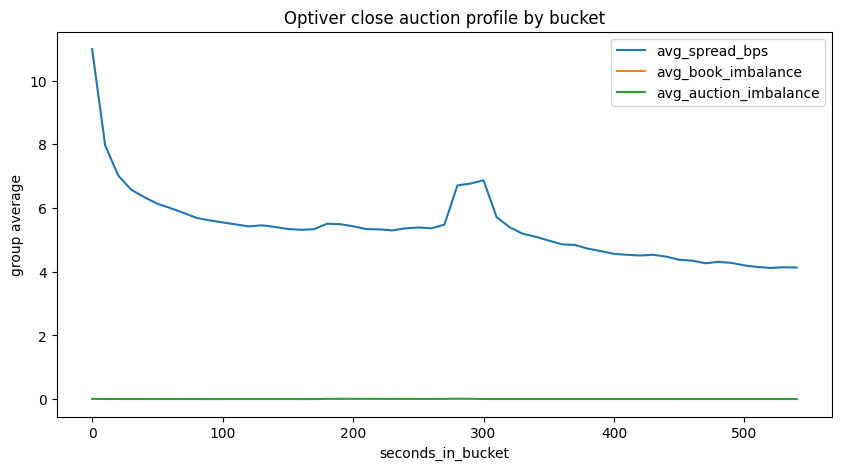

In [3]:
ax = bucket_profile.plot(
    x="seconds_in_bucket",
    y=["avg_spread_bps", "avg_book_imbalance", "avg_auction_imbalance"],
    figsize=(10, 5),
    title="Optiver close auction profile by bucket",
)
ax.set_xlabel("seconds_in_bucket")
ax.set_ylabel("group average")
plt.show()


## 2. Stocks with the most missing auction prices


In [4]:
%%ibex --as pandas --out null_summary
extern fn read_csv(path: String, nulls: String) -> DataFrame from "csv.hpp";

let train = read_csv("../kaggle/data/train.csv", "<empty>");

let rows_by_stock = train[select { rows = count() }, by stock_id];
let far_nulls = train[filter { far_price is null }, select { far_null_rows = count() }, by stock_id];
let near_nulls = train[filter { near_price is null }, select { near_null_rows = count() }, by stock_id];

let merged = rows_by_stock
    left join far_nulls on stock_id
    left join near_nulls on stock_id;

merged[update {
    far_null_rows  = fill_null(far_null_rows, 0),
    near_null_rows = fill_null(near_null_rows, 0),
    far_null_pct   = 100.0 * far_null_rows / rows,
    near_null_pct  = 100.0 * near_null_rows / rows
}]
[order { far_null_pct desc }]
[select { stock_id, rows, far_null_pct, near_null_pct }]
[filter stock_id >= 0];


,stock_id,rows,far_null_pct,near_null_pct
0,143,26455,59.837460,54.545455
1,86,26455,58.019278,54.545455
2,11,26455,57.731998,54.545455
3,31,26455,57.403137,54.545455
4,78,26235,57.289880,54.545455
...,...,...,...,...
195,14,26455,54.549235,54.545455
196,112,26455,54.549235,54.545455
197,142,26455,54.549235,54.545455
198,160,26455,54.549235,54.545455


,stock_id,rows,far_null_pct,near_null_pct
0,143,26455,59.837460,54.545455
1,86,26455,58.019278,54.545455
2,11,26455,57.731998,54.545455
3,31,26455,57.403137,54.545455
4,78,26235,57.289880,54.545455
...,...,...,...,...
195,14,26455,54.549235,54.545455
196,112,26455,54.549235,54.545455
197,142,26455,54.549235,54.545455
198,160,26455,54.549235,54.545455


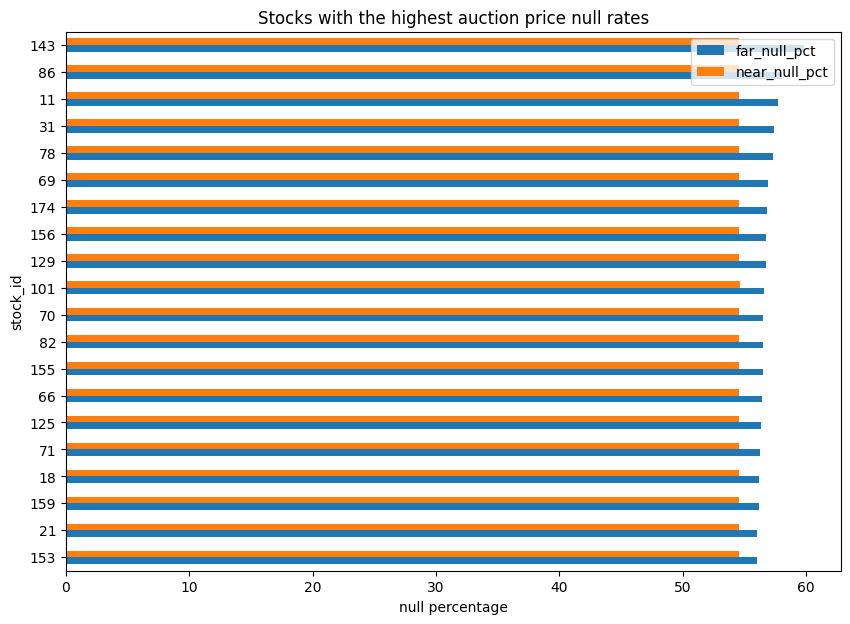

In [5]:
top_nulls = null_summary.head(20).sort_values("far_null_pct")
ax = top_nulls.plot(
    kind="barh",
    x="stock_id",
    y=["far_null_pct", "near_null_pct"],
    figsize=(10, 7),
    title="Stocks with the highest auction price null rates",
)
ax.set_xlabel("null percentage")
ax.set_ylabel("stock_id")
plt.show()


## 3. Dates with the largest cross-sectional target dispersion


In [6]:
%%ibex --as pandas --out daily_dispersion
extern fn read_csv(path: String, nulls: String) -> DataFrame from "csv.hpp";

let train = read_csv("../kaggle/data/train.csv", "<empty>");

let book = train[update {
    spread_bps = 10000.0 * (ask_price - bid_price) / wap,
    depth      = bid_size + ask_size,
    target_sq  = target * target
}];

book[select {
    avg_spread_bps      = mean(spread_bps),
    avg_depth           = mean(depth),
    avg_target          = mean(target),
    mean_squared_target = mean(target_sq)
}, by date_id]
[order { mean_squared_target desc }];


,date_id,avg_spread_bps,avg_depth,avg_target,mean_squared_target
0,96,9.090365,92282.688366,0.400683,484.858614
1,119,7.506979,91846.744545,-0.030021,336.169925
2,122,11.642632,64721.447894,-0.925404,281.953305
3,83,8.009483,103177.622011,-1.189583,271.083969
4,33,7.235507,107582.601943,0.162545,249.339892
...,...,...,...,...,...
476,52,4.182316,113702.349351,0.066769,46.132913
477,49,4.420714,103051.817022,0.398642,45.090892
478,54,4.172086,120260.198358,-0.116935,44.178825
479,55,3.993837,116257.152617,-0.072826,43.630186


,date_id,avg_spread_bps,avg_depth,avg_target,mean_squared_target
0,96,9.090365,92282.688366,0.400683,484.858614
1,119,7.506979,91846.744545,-0.030021,336.169925
2,122,11.642632,64721.447894,-0.925404,281.953305
3,83,8.009483,103177.622011,-1.189583,271.083969
4,33,7.235507,107582.601943,0.162545,249.339892
...,...,...,...,...,...
476,52,4.182316,113702.349351,0.066769,46.132913
477,49,4.420714,103051.817022,0.398642,45.090892
478,54,4.172086,120260.198358,-0.116935,44.178825
479,55,3.993837,116257.152617,-0.072826,43.630186


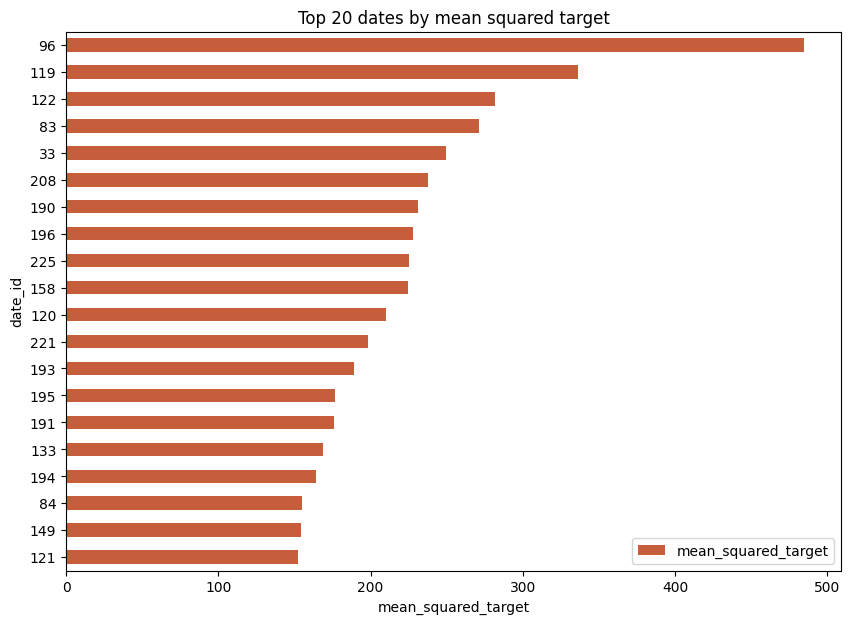

In [9]:
top_days = daily_dispersion.head(20).sort_values("mean_squared_target")
ax = top_days.plot(
    kind="barh",
    x="date_id",
    y="mean_squared_target",
    figsize=(10, 7),
    title="Top 20 dates by mean squared target",
    color="#c65d3b",
)
ax.set_xlabel("mean_squared_target")
ax.set_ylabel("date_id")
plt.show()
